# SVM-based MEWMA control chart with $ARL_0$ calibration

This notebook implements a **support-vector-machine-enhanced multivariate EWMA (SVM-MEWMA)** control chart.

It includes Phase I model building and $ARL_0$ calibration, Phase II monitoring for shifts $delta=0,0.2,\ldots,3.0$, ARL summaries, machine-learning performance measures, box-plots, curves, and commented code.


## Method summary

A one-class SVM is trained on Phase I in-control observations. Its signed decision score is appended to the standardized process variables and monitored by MEWMA:

$$
z_t=\lambda y_t+(1-\lambda)z_{t-1},\qquad T_t^2=(z_t-\mu_y)^\top\Sigma_z^{-1}(z_t-\mu_y),
$$

where $\Sigma_z=\lambda(2-\lambda)^{-1}\Sigma_y$. The control limit $h$ is calibrated by simulation to target $ARL_0=370$ for $\lambda=0.05$.


In [ ]:
# & "C:\Users\steph\anaconda3\Scripts\conda.exe" install numpy=1.26 #
# install numpy 1.26 to avoid "ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found." error
# %pip install xelatex

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xelatex (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for xelatex


In [7]:
# Core scientific stack
import numpy as np
import pandas as pd

# Machine learning and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Plotting
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 20260430
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)


## User-adjustable settings

Increase the Monte Carlo repetitions for publication-grade estimates. The defaults are designed to be practical on a laptop while still showing the complete workflow.

In [8]:
# Simulation design
P = 4                         # Number of original process variables
N_PHASE1 = 2000               # Historical Phase I in-control observations
STREAM_MAX_LEN = 3000         # Maximum stream length used to estimate run length
SHIFT_DELTAS = np.round(np.arange(0.0, 3.0 + 0.0001, 0.2), 1)

# MEWMA chart settings
LAMBDA = 0.05                 # Requested EWMA smoothing parameter
TARGET_ARL0 = 370             # Requested in-control average run length

# Monte Carlo settings
N_CALIBRATION_REPS = 300    # Increase to 5000+ for more stable ARL0 calibration
N_PHASE2_REPS = 500           # Increase to 2000+ for smoother OOC curves

# One-class SVM settings
OCSVM_NU = 0.03               # Approximate fraction of Phase I points allowed outside boundary
OCSVM_GAMMA = "scale"         # Robust default RBF kernel width


## Helper functions

In [9]:
def make_covariance_matrix(p: int, rho: float = 0.35) -> np.ndarray:
    """Create an AR(1)-style positive-definite covariance matrix."""
    idx = np.arange(p)
    return rho ** np.abs(np.subtract.outer(idx, idx))


def simulate_process(n: int, p: int, delta: float = 0.0, shift_direction=None, random_state=None) -> np.ndarray:
    """Simulate multivariate process observations with optional mean shift."""
    rs = random_state if random_state is not None else np.random.default_rng()
    cov = make_covariance_matrix(p)
    if shift_direction is None:
        shift_direction = np.zeros(p)
        shift_direction[0] = 1.0
    shift_direction = np.asarray(shift_direction, dtype=float)
    shift_direction = shift_direction / np.linalg.norm(shift_direction)
    mean = delta * shift_direction
    return rs.multivariate_normal(mean=mean, cov=cov, size=n)


def fit_phase1_model(X_phase1: np.ndarray):
    """
    Fit the Phase I standardizer and one-class SVM.

    Steps:
    1. Standardize the Phase I variables.
    2. Fit a one-class SVM to learn the in-control region.
    3. Append the SVM decision score to the standardized variables.
    4. Estimate the in-control mean and covariance of the augmented vector.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_phase1)

    ocsvm = OneClassSVM(kernel="rbf", nu=OCSVM_NU, gamma=OCSVM_GAMMA)
    ocsvm.fit(X_std)

    # Positive scores are more in-control-like; negative scores are more abnormal.
    svm_score = ocsvm.decision_function(X_std).reshape(-1, 1)
    Y = np.hstack([X_std, svm_score])

    # Optional robust Phase I cleaning: remove the most extreme 1% of augmented observations.
    center0 = Y.mean(axis=0)
    cov0 = np.cov(Y, rowvar=False)
    inv_cov0 = np.linalg.pinv(cov0)
    d2 = np.einsum("ij,jk,ik->i", Y - center0, inv_cov0, Y - center0)
    keep = d2 <= np.quantile(d2, 0.99)
    Y_clean = Y[keep]

    return {
        "scaler": scaler,
        "ocsvm": ocsvm,
        "mu_y": Y_clean.mean(axis=0),
        "cov_y": np.cov(Y_clean, rowvar=False),
        "Y_phase1": Y,
        "Y_phase1_clean": Y_clean,
        "phase1_keep_mask": keep,
    }


def transform_to_augmented_features(X: np.ndarray, model: dict) -> np.ndarray:
    """Standardize raw data and append the one-class SVM decision score."""
    X_std = model["scaler"].transform(X)
    svm_score = model["ocsvm"].decision_function(X_std).reshape(-1, 1)
    return np.hstack([X_std, svm_score])


def mewma_statistic(Y: np.ndarray, mu_y: np.ndarray, cov_y: np.ndarray, lam: float = 0.05) -> np.ndarray:
    """Compute MEWMA T-squared statistics for a sequence of augmented vectors."""
    q = Y.shape[1]
    z = mu_y.copy()  # Start the EWMA at the in-control center.

    # Steady-state covariance of z_t, with a small ridge for numerical stability.
    cov_z = (lam / (2.0 - lam)) * cov_y + 1e-8 * np.eye(q)
    inv_cov_z = np.linalg.pinv(cov_z)

    t2_values = np.empty(Y.shape[0])
    for t, y_t in enumerate(Y):
        z = lam * y_t + (1.0 - lam) * z
        diff = z - mu_y
        t2_values[t] = diff @ inv_cov_z @ diff
    return t2_values


def run_length_for_stream(X_stream: np.ndarray, model: dict, h: float, lam: float = 0.05) -> int:
    """Return the first alarm time; if no alarm occurs, return the stream length."""
    Y = transform_to_augmented_features(X_stream, model)
    t2 = mewma_statistic(Y, model["mu_y"], model["cov_y"], lam=lam)
    alarm_positions = np.flatnonzero(t2 > h)
    return len(X_stream) if len(alarm_positions) == 0 else int(alarm_positions[0] + 1)


def estimate_arl(delta: float, model: dict, h: float, n_rep: int, stream_len: int, lam: float, random_state) -> np.ndarray:
    """Estimate the run-length distribution for one shift size."""
    run_lengths = np.empty(n_rep, dtype=int)
    for i in range(n_rep):
        X_stream = simulate_process(stream_len, P, delta=delta, random_state=random_state)
        run_lengths[i] = run_length_for_stream(X_stream, model, h=h, lam=lam)
    return run_lengths


def calibrate_control_limit(model: dict, target_arl0: float, lam: float, n_rep: int, stream_len: int, random_state):
    """Calibrate h by bisection so the estimated ARL0 is close to target_arl0."""
    low_h, high_h = 0.1, 20.0
    history = []

    # Expand upper bracket until the false alarm rate is low enough.
    while True:
        rl = estimate_arl(0.0, model, high_h, max(100, n_rep // 5), stream_len, lam, random_state)
        if rl.mean() >= target_arl0 or high_h > 500:
            break
        high_h *= 1.5

    # Bisection search. Larger h implies larger ARL0.
    for iteration in range(18):
        mid_h = 0.5 * (low_h + high_h)
        rl = estimate_arl(0.0, model, mid_h, n_rep, stream_len, lam, random_state)
        arl = rl.mean()
        history.append({"iteration": iteration + 1, "h": mid_h, "estimated_arl0": arl})
        if arl < target_arl0:
            low_h = mid_h
        else:
            high_h = mid_h

    return 0.5 * (low_h + high_h), pd.DataFrame(history)


## Phase I analysis

**Phase I steps**

1. Collect historical observations believed to be in-control.
2. Standardize all variables using only Phase I data.
3. Train the one-class SVM on standardized Phase I observations.
4. Create the augmented monitoring vector by appending the SVM decision score.
5. Estimate the in-control mean and covariance of the augmented vector.
6. Calibrate the MEWMA control limit to achieve $ARL_0 \approx 370$ for $\lambda=0.05$.


In [10]:
# Generate Phase I in-control data.
# Replace this with your own Phase I data import if available, e.g.:
# X_phase1 = pd.read_csv("phase1.csv").to_numpy()
X_phase1 = simulate_process(N_PHASE1, P, delta=0.0, random_state=rng)

phase1_model = fit_phase1_model(X_phase1)

print("Phase I raw data shape:", X_phase1.shape)
print("Augmented Phase I feature shape:", phase1_model["Y_phase1"].shape)
print("Clean Phase I observations retained:", phase1_model["phase1_keep_mask"].sum(), "of", N_PHASE1)


Phase I raw data shape: (2000, 4)
Augmented Phase I feature shape: (2000, 5)
Clean Phase I observations retained: 1980 of 2000


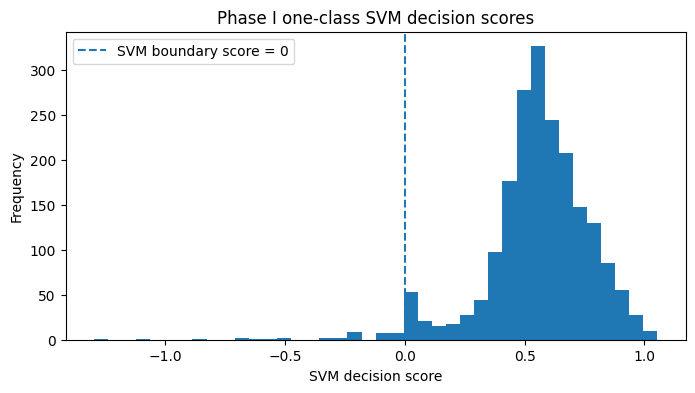

In [11]:
# Visualize Phase I SVM decision scores.
phase1_scores = phase1_model["Y_phase1"][:, -1]

plt.figure(figsize=(8, 4))
plt.hist(phase1_scores, bins=40)
plt.axvline(0, linestyle="--", label="SVM boundary score = 0")
plt.title("Phase I one-class SVM decision scores")
plt.xlabel("SVM decision score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [12]:
# Calibrate h for ARL0 = 370.
# This is the most computationally intensive cell.
h_star, calibration_history = calibrate_control_limit(
    model=phase1_model,
    target_arl0=TARGET_ARL0,
    lam=LAMBDA,
    n_rep=N_CALIBRATION_REPS,
    stream_len=STREAM_MAX_LEN,
    random_state=rng,
)

print(f"Calibrated control limit h = {h_star:.4f}")
display(calibration_history.tail())


Calibrated control limit h = 22.5118


,iteration,h,estimated_arl0
13,14,22.5122,377.2500
14,15,22.5113,365.0567
15,16,22.5118,356.5367
16,17,22.5120,408.8200
17,18,22.5119,391.9733


In [13]:
# Confirm the calibrated ARL0 with a fresh simulation.
rl0_confirm = estimate_arl(
    delta=0.0,
    model=phase1_model,
    h=h_star,
    n_rep=N_PHASE2_REPS,
    stream_len=STREAM_MAX_LEN,
    lam=LAMBDA,
    random_state=rng,
)

print(f"Confirmation ARL0 estimate: {rl0_confirm.mean():.2f}")
print(f"Median in-control run length: {np.median(rl0_confirm):.2f}")
print(f"False alarm probability within {STREAM_MAX_LEN} points: {np.mean(rl0_confirm < STREAM_MAX_LEN):.3f}")


Confirmation ARL0 estimate: 359.59
Median in-control run length: 258.50
False alarm probability within 3000 points: 1.000


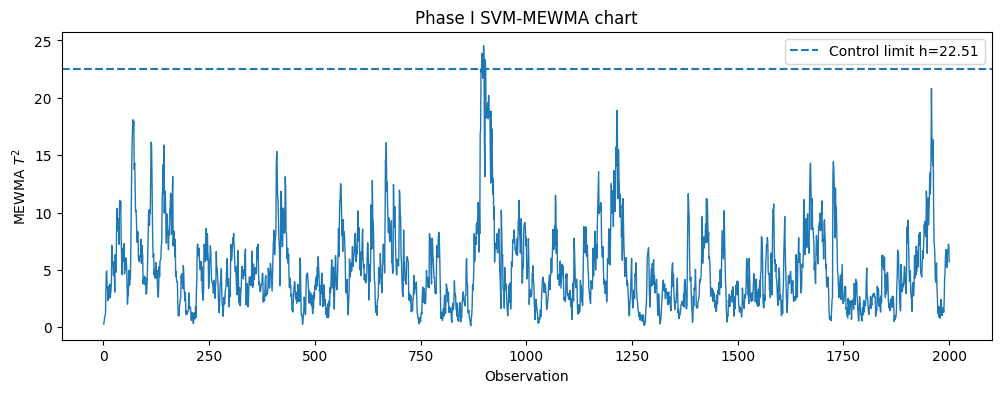

Number of Phase I points above calibrated limit: 6


In [14]:
# Phase I MEWMA chart diagnostic.
Y_phase1 = transform_to_augmented_features(X_phase1, phase1_model)
t2_phase1 = mewma_statistic(Y_phase1, phase1_model["mu_y"], phase1_model["cov_y"], lam=LAMBDA)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, len(t2_phase1) + 1), t2_phase1, linewidth=1)
plt.axhline(h_star, linestyle="--", label=f"Control limit h={h_star:.2f}")
plt.title("Phase I SVM-MEWMA chart")
plt.xlabel("Observation")
plt.ylabel("MEWMA $T^2$")
plt.legend()
plt.show()

print("Number of Phase I points above calibrated limit:", int(np.sum(t2_phase1 > h_star)))


## Phase II analysis

**Phase II steps**

1. Keep the Phase I scaler, SVM, augmented-feature mean, covariance, and control limit fixed.
2. For each new observation, compute standardized variables and the SVM decision score.
3. Update the MEWMA statistic recursively.
4. Signal an alarm when $T_t^2 > h$.
5. Evaluate shifts $\delta=0,0.2,\ldots,3.0$ using ARL, median RL, SDRL, alarm probability, accuracy, precision, recall, F1, and AUC versus in-control.


In [15]:
def evaluate_ml_metrics_for_delta(delta: float, model: dict, h: float, n_streams: int, stream_len: int, lam: float, random_state):
    """Estimate pointwise ML metrics using T2 > h as the predicted out-of-control label."""
    y_true_all, y_pred_all, score_all = [], [], []
    for _ in range(n_streams):
        X_stream = simulate_process(stream_len, P, delta=delta, random_state=random_state)
        Y_stream = transform_to_augmented_features(X_stream, model)
        t2_stream = mewma_statistic(Y_stream, model["mu_y"], model["cov_y"], lam=lam)
        y_true = np.full(stream_len, int(delta > 0.0))
        y_pred = (t2_stream > h).astype(int)
        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
        score_all.append(t2_stream)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    score_all = np.concatenate(score_all)
    return {
        "accuracy": accuracy_score(y_true_all, y_pred_all),
        "precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "f1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "score": score_all,
    }


def phase2_experiment(deltas, model, h, n_rep, stream_len, lam, random_state):
    """Run Phase II Monte Carlo experiments for all shifts."""
    summary_rows, run_length_rows = [], []
    ml_stream_len = min(400, stream_len)
    ml_streams = max(50, min(200, n_rep // 2))

    for delta in deltas:
        print(f"Evaluating delta={delta:.1f}")
        rls = estimate_arl(delta, model, h, n_rep=n_rep, stream_len=stream_len, lam=lam, random_state=random_state)
        ml = evaluate_ml_metrics_for_delta(delta, model, h, n_streams=ml_streams, stream_len=ml_stream_len, lam=lam, random_state=random_state)

        for rl in rls:
            run_length_rows.append({"delta": delta, "run_length": rl})

        summary_rows.append({
            "delta": delta,
            "ARL": rls.mean(),
            "median_RL": np.median(rls),
            "SDRL": rls.std(ddof=1),
            "alarm_probability": np.mean(rls < stream_len),
            "accuracy": ml["accuracy"],
            "precision": ml["precision"],
            "recall": ml["recall"],
            "f1": ml["f1"],
        })

    summary = pd.DataFrame(summary_rows)
    run_lengths = pd.DataFrame(run_length_rows)

    # Compute AUC for each delta>0 by comparing that shifted process against an equal-size IC sample.
    auc_values = []
    for delta in deltas:
        if delta == 0:
            auc_values.append(np.nan)
            continue
        X_ic = simulate_process(1000, P, delta=0.0, random_state=random_state)
        X_oc = simulate_process(1000, P, delta=delta, random_state=random_state)
        t2_ic = mewma_statistic(transform_to_augmented_features(X_ic, model), model["mu_y"], model["cov_y"], lam=lam)
        t2_oc = mewma_statistic(transform_to_augmented_features(X_oc, model), model["mu_y"], model["cov_y"], lam=lam)
        y_auc = np.r_[np.zeros_like(t2_ic), np.ones_like(t2_oc)]
        s_auc = np.r_[t2_ic, t2_oc]
        auc_values.append(roc_auc_score(y_auc, s_auc))
    summary["auc_vs_ic"] = auc_values
    return summary, run_lengths


In [16]:
phase2_summary, phase2_run_lengths = phase2_experiment(
    deltas=SHIFT_DELTAS,
    model=phase1_model,
    h=h_star,
    n_rep=N_PHASE2_REPS,
    stream_len=STREAM_MAX_LEN,
    lam=LAMBDA,
    random_state=rng,
)

display(phase2_summary)


Evaluating delta=0.0
Evaluating delta=0.2
Evaluating delta=0.4
Evaluating delta=0.6
Evaluating delta=0.8
Evaluating delta=1.0
Evaluating delta=1.2
Evaluating delta=1.4
Evaluating delta=1.6
Evaluating delta=1.8
Evaluating delta=2.0
Evaluating delta=2.2
Evaluating delta=2.4
Evaluating delta=2.6
Evaluating delta=2.8
Evaluating delta=3.0


,delta,ARL,median_RL,SDRL,alarm_probability,accuracy,precision,recall,f1,auc_vs_ic
0,0.0,363.388,237.5,373.8671,1.0,0.9853,0.0,0.0000,0.0000,NaN
1,0.2,228.198,159.5,201.3057,1.0,0.0297,1.0,0.0297,0.0577,0.5136
2,0.4,85.248,67.0,67.7093,1.0,0.1305,1.0,0.1305,0.2309,0.8472
3,0.6,41.116,35.0,24.3953,1.0,0.4287,1.0,0.4287,0.6001,0.9744
4,0.8,26.504,25.0,12.4563,1.0,0.8235,1.0,0.8235,0.9032,0.9833
5,1.0,17.986,17.0,7.8233,1.0,0.9416,1.0,0.9416,0.9699,0.9939
6,1.2,13.572,13.0,5.1790,1.0,0.9648,1.0,0.9648,0.9821,0.9959
7,1.4,11.120,11.0,4.0237,1.0,0.9732,1.0,0.9732,0.9864,0.9966
8,1.6,9.170,9.0,3.1839,1.0,0.9792,1.0,0.9792,0.9895,0.9961
9,1.8,7.476,7.0,2.8230,1.0,0.9840,1.0,0.9840,0.9919,0.9998


In [17]:
# Save numerical results.
phase2_summary.to_csv("svm_mewma_phase2_summary.csv", index=False)
phase2_run_lengths.to_csv("svm_mewma_run_lengths.csv", index=False)
calibration_history.to_csv("svm_mewma_calibration_history.csv", index=False)


## Graphs

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\steph\AppData\Local\Temp\ipykernel_37920\3769228226.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel("Shift magnitude $\delta$")


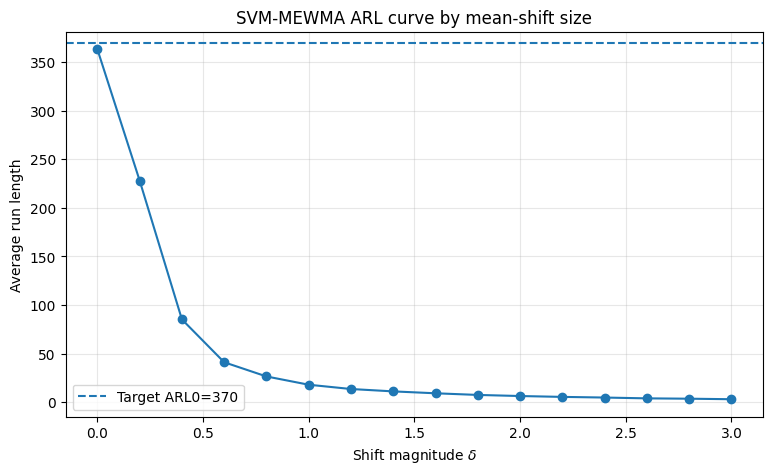

In [18]:
# ARL curve across shifts.
plt.figure(figsize=(9, 5))
plt.plot(phase2_summary["delta"], phase2_summary["ARL"], marker="o")
plt.axhline(TARGET_ARL0, linestyle="--", label=f"Target ARL0={TARGET_ARL0}")
plt.title("SVM-MEWMA ARL curve by mean-shift size")
plt.xlabel("Shift magnitude $\delta$")
plt.ylabel("Average run length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\steph\AppData\Local\Temp\ipykernel_37920\2513353123.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel("Shift magnitude $\delta$")
C:\Users\steph\AppData\Local\Temp\ipykernel_37920\2513353123.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[f"{d:.1f}" for d in SHIFT_DELTAS], showfliers=False)


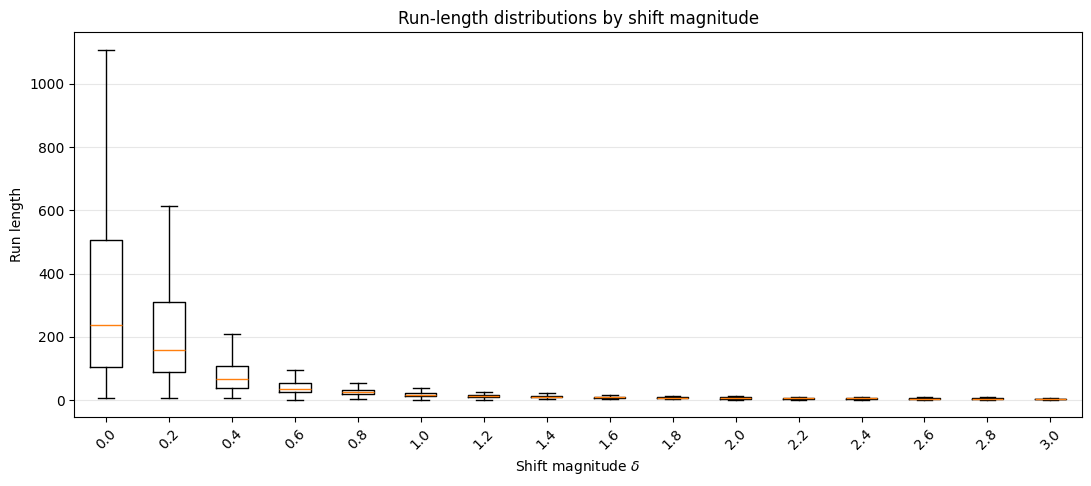

In [19]:
# Box-plots of run lengths for different shifts.
box_data = [phase2_run_lengths.loc[phase2_run_lengths["delta"] == d, "run_length"].values for d in SHIFT_DELTAS]
plt.figure(figsize=(13, 5))
plt.boxplot(box_data, labels=[f"{d:.1f}" for d in SHIFT_DELTAS], showfliers=False)
plt.title("Run-length distributions by shift magnitude")
plt.xlabel("Shift magnitude $\delta$")
plt.ylabel("Run length")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\steph\AppData\Local\Temp\ipykernel_37920\380273087.py:5: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel("Shift magnitude $\delta$")


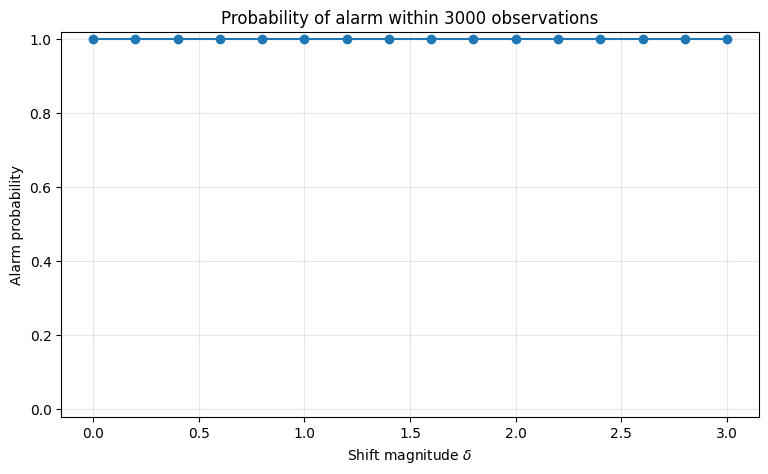

In [20]:
# Alarm probability curve.
plt.figure(figsize=(9, 5))
plt.plot(phase2_summary["delta"], phase2_summary["alarm_probability"], marker="o")
plt.title(f"Probability of alarm within {STREAM_MAX_LEN} observations")
plt.xlabel("Shift magnitude $\delta$")
plt.ylabel("Alarm probability")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.show()


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\steph\AppData\Local\Temp\ipykernel_37920\3875760308.py:7: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel("Shift magnitude $\delta$")


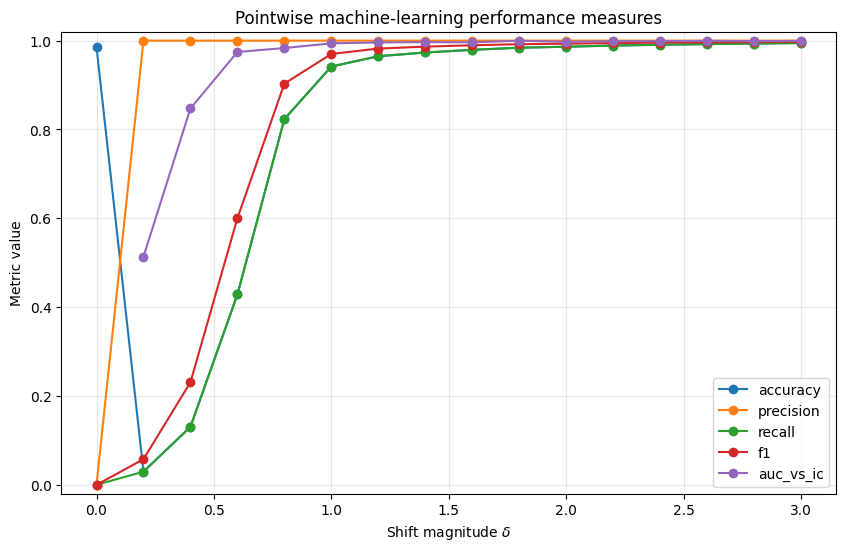

In [21]:
# Machine-learning performance curves.
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc_vs_ic"]
plt.figure(figsize=(10, 6))
for metric in metrics_to_plot:
    plt.plot(phase2_summary["delta"], phase2_summary[metric], marker="o", label=metric)
plt.title("Pointwise machine-learning performance measures")
plt.xlabel("Shift magnitude $\delta$")
plt.ylabel("Metric value")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


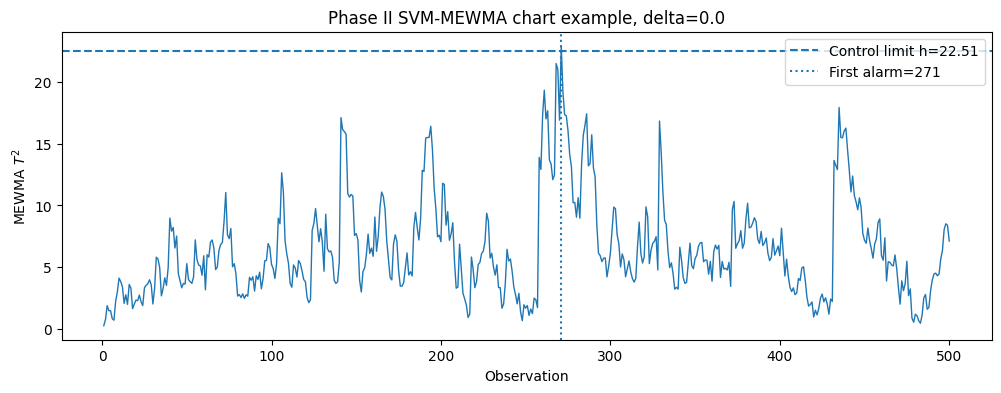

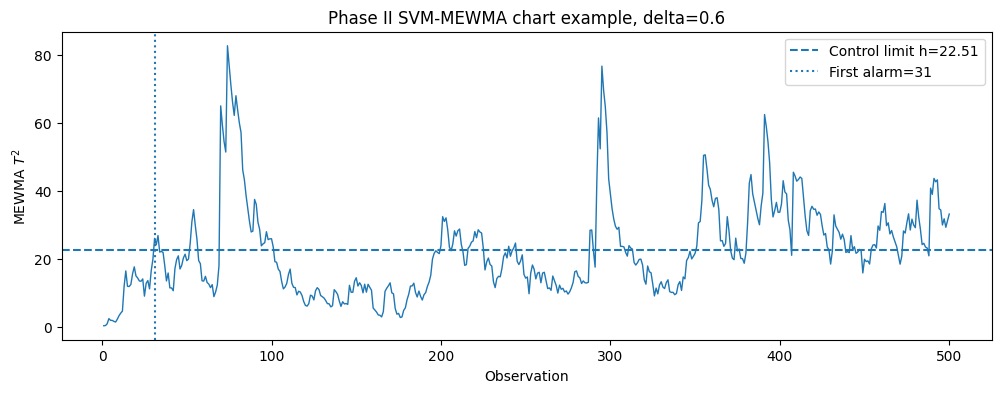

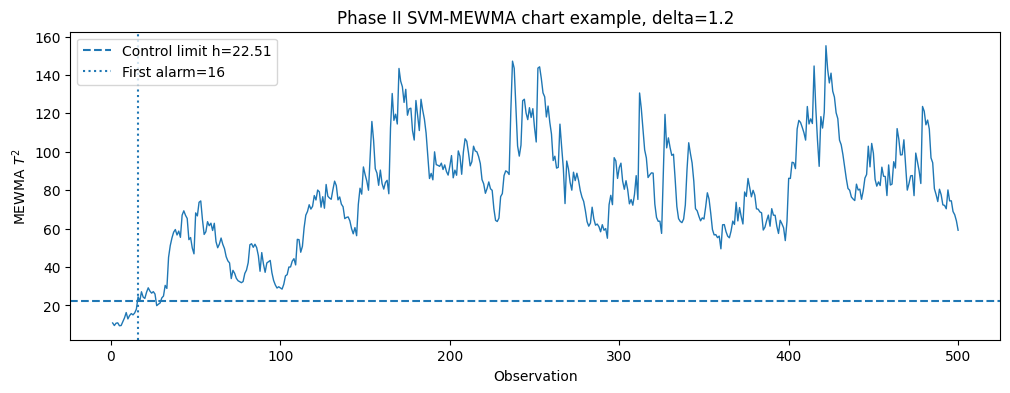

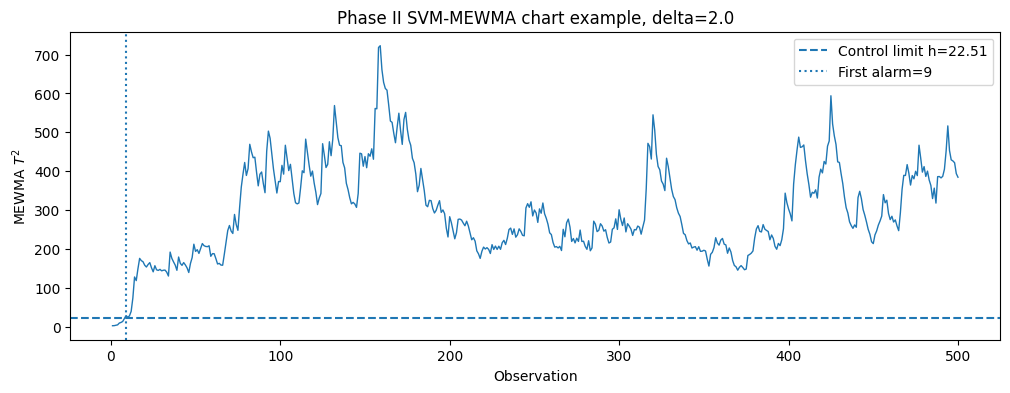

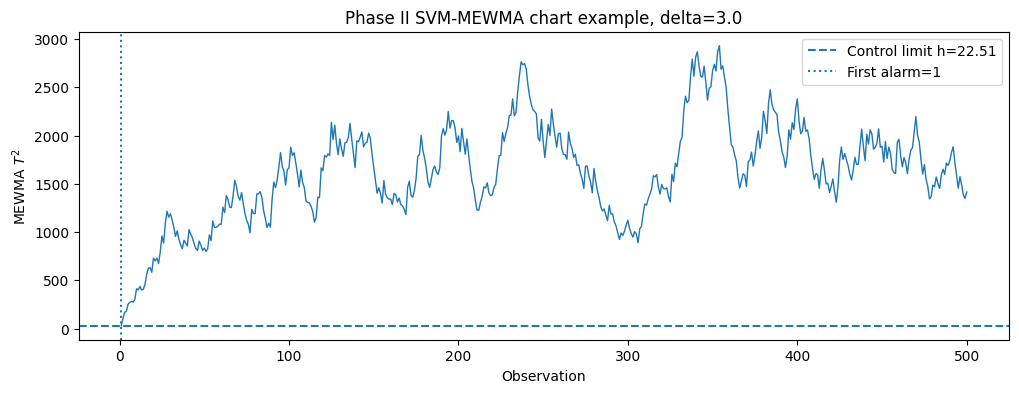

In [22]:
# Example Phase II charts for selected shifts.
selected_deltas = [0.0, 0.6, 1.2, 2.0, 3.0]
example_len = 500
for delta in selected_deltas:
    X_ex = simulate_process(example_len, P, delta=delta, random_state=rng)
    Y_ex = transform_to_augmented_features(X_ex, phase1_model)
    t2_ex = mewma_statistic(Y_ex, phase1_model["mu_y"], phase1_model["cov_y"], lam=LAMBDA)
    first_alarm = np.flatnonzero(t2_ex > h_star)

    plt.figure(figsize=(12, 4))
    plt.plot(np.arange(1, example_len + 1), t2_ex, linewidth=1)
    plt.axhline(h_star, linestyle="--", label=f"Control limit h={h_star:.2f}")
    if len(first_alarm) > 0:
        plt.axvline(first_alarm[0] + 1, linestyle=":", label=f"First alarm={first_alarm[0] + 1}")
    plt.title(f"Phase II SVM-MEWMA chart example, delta={delta:.1f}")
    plt.xlabel("Observation")
    plt.ylabel("MEWMA $T^2$")
    plt.legend()
    plt.show()


## Interpretation template

- The calibrated `h_star` should give an estimated in-control ARL close to 370 for $\lambda=0.05$.
- At $\delta=0$, alarms are false alarms, so the ARL should be near $ARL_0$.
- As $\delta$ increases, ARL should decrease because larger shifts are easier to detect.
- Recall, F1, and AUC should generally improve as the shift becomes larger.
- For small shifts, precision and recall can be low because the shifted distribution is close to in-control behavior.

For a final study, report the random seed, process dimension, covariance structure, SVM hyperparameters, Monte Carlo repetitions, stream length, calibrated limit, and ARL/metric table.


## Applying to real data

Replace the simulated Phase I line with your own matrix of in-control observations:

```python
X_phase1 = pd.read_csv("phase1.csv").to_numpy()
```

Then keep the fitted Phase I objects fixed and monitor Phase II data as follows:

```python
Y_new = transform_to_augmented_features(X_phase2, phase1_model)
t2_new = mewma_statistic(Y_new, phase1_model["mu_y"], phase1_model["cov_y"], lam=LAMBDA)
alarms = t2_new > h_star
```
